
# 03 — Baseline Forecasting

## Objective
Establish simple forecasting benchmarks for next-hour electricity demand.

## Forecasting task
Predict the average electricity demand for the next hour using
historical demand observations and compare forecasts against actual demand.

## Baseline methods
1. Naive forecast (persistence)
2. Seasonal naive forecast (daily seasonality)

## Evaluation metrics
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

## Data source
Data/Processed/hourly_demand_features.csv

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:

# Load the feature-engineered dataset
data = pd.read_csv(
    "../Data/Processed/hourly_demand_features.csv",
    index_col=0,
    parse_dates=True
)

# Inspect the dataset
print("Dataset shape:", data.shape)
print("\nFirst five rows:")
display(data.head())

print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

Dataset shape: (34896, 15)

First five rows:


,total_demand,target,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,hour,day_of_week,is_weekend,hour_sin,hour_cos,rolling_mean_24,rolling_std_24
2011-01-08 00:00:00,86403.301624,72534.984171,111609.594412,130176.983542,141034.492592,85716.807571,85490.070525,69019.423424,0,5,1,0.000000,1.000000,120015.695552,29768.012259
2011-01-08 01:00:00,72534.984171,69325.030607,86403.301624,111609.594412,130176.983542,73297.911807,72602.273897,66344.627687,1,5,1,0.258819,0.965926,119983.906900,29820.431514
2011-01-08 02:00:00,69325.030607,68554.184257,72534.984171,86403.301624,111609.594412,70543.526944,69897.630958,65981.054883,2,5,1,0.500000,0.866025,119933.136219,29909.171077
2011-01-08 03:00:00,68554.184257,69033.522311,69325.030607,72534.984171,86403.301624,70242.037536,69467.257186,66576.533566,3,5,1,0.707107,0.707107,119862.809000,30032.821574
2011-01-08 04:00:00,69033.522311,76272.763924,68554.184257,69325.030607,72534.984171,68884.017033,69493.357908,64963.552675,4,5,1,0.866025,0.500000,119869.038386,30021.801334



Column names:
['total_demand', 'target', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'rolling_mean_24', 'rolling_std_24']

Data types:
total_demand       float64
target             float64
lag_1              float64
lag_2              float64
lag_3              float64
lag_24             float64
lag_48             float64
lag_168            float64
hour                 int64
day_of_week          int64
is_weekend           int64
hour_sin           float64
hour_cos           float64
rolling_mean_24    float64
rolling_std_24     float64
dtype: object

Missing values:
total_demand       0
target             0
lag_1              0
lag_2              0
lag_3              0
lag_24             0
lag_48             0
lag_168            0
hour               0
day_of_week        0
is_weekend         0
hour_sin           0
hour_cos           0
rolling_mean_24    0
rolling_std_24     0
dtype: int64


In [3]:

print("Index type:", type(data.index))
print("Index sorted:", data.index.is_monotonic_increasing)
print("Duplicate timestamps:", data.index.duplicated().sum())
print("First timestamp:", data.index.min())
print("Last timestamp:", data.index.max())

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index sorted: True
Duplicate timestamps: 0
First timestamp: 2011-01-08 00:00:00
Last timestamp: 2014-12-31 23:00:00



## 4. Chronological Train-Test Split

We use an 80/20 chronological split to evaluate forecasting performance
on a later period that was not used to establish the initial benchmarks.

The data is not shuffled because time order is important in forecasting.

In [4]:

# Remove rows where the target is missing
data = data.dropna(subset=["target"]).copy()

# Define the split point
split_index = int(len(data) * 0.80)

# Split chronologically
train_data = data.iloc[:split_index].copy()
test_data = data.iloc[split_index:].copy()

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

print("\nTraining period:")
print(train_data.index.min(), "to", train_data.index.max())

print("\nTesting period:")
print(test_data.index.min(), "to", test_data.index.max())

Training observations: 27916
Testing observations: 6980

Training period:
2011-01-08 00:00:00 to 2014-03-16 03:00:00

Testing period:
2014-03-16 04:00:00 to 2014-12-31 23:00:00



## 5. Baseline 1 — Naive Forecast

The naive forecast assumes that demand in the next hour will equal
the demand observed in the current hour.

This provides a simple persistence benchmark against which more
advanced forecasting models can be evaluated.

In [5]:

# Actual next-hour demand
y_test = test_data["target"]

# Predict next-hour demand using current-hour demand
naive_predictions = test_data["total_demand"]

print("Actual demand:")
display(y_test.head())

print("\nNaive predictions:")
display(naive_predictions.head())

Actual demand:


2014-03-16 04:00:00    111525.398404
2014-03-16 05:00:00    126897.471138
2014-03-16 06:00:00    140579.737442
2014-03-16 07:00:00    149643.211466
2014-03-16 08:00:00    183540.864585
Name: target, dtype: float64


Naive predictions:


2014-03-16 04:00:00    107756.532059
2014-03-16 05:00:00    111525.398404
2014-03-16 06:00:00    126897.471138
2014-03-16 07:00:00    140579.737442
2014-03-16 08:00:00    149643.211466
Name: total_demand, dtype: float64


## 6. Baseline 2 — Seasonal Naive Forecast

The seasonal naive forecast assumes that demand will repeat the pattern
observed at the corresponding hour on the previous day.

Because the target represents next-hour demand, the previous day's
corresponding target is obtained using a 24-row shift of the target series.

In [6]:

# Previous-day demand aligned with the next-hour target
seasonal_predictions = data["target"].shift(24).iloc[split_index:]

# Align the predictions and actual values
seasonal_predictions = seasonal_predictions.reindex(y_test.index)

# Confirm that forecasts exist for the test period
print("Missing seasonal predictions:", seasonal_predictions.isna().sum())

display(
    pd.DataFrame({
        "actual_demand": y_test,
        "naive_prediction": naive_predictions,
        "seasonal_prediction": seasonal_predictions
    }).head(10)
)

Missing seasonal predictions: 0


,actual_demand,naive_prediction,seasonal_prediction
2014-03-16 04:00:00,111525.398404,107756.532059,123838.904112
2014-03-16 05:00:00,126897.471138,111525.398404,142119.844969
2014-03-16 06:00:00,140579.737442,126897.471138,157129.409908
2014-03-16 07:00:00,149643.211466,140579.737442,164758.937232
2014-03-16 08:00:00,183540.864585,149643.211466,195218.862242
2014-03-16 09:00:00,209244.847104,183540.864585,214353.806477
2014-03-16 10:00:00,242385.296131,209244.847104,236506.594697
2014-03-16 11:00:00,242442.759354,242385.296131,240714.075954
2014-03-16 12:00:00,241607.662546,242442.759354,238463.147551
2014-03-16 13:00:00,239654.388901,241607.662546,242574.668466


In [7]:

# Check that all forecasts are available
assert not y_test.isna().any()
assert not naive_predictions.isna().any()
assert not seasonal_predictions.isna().any()

# Calculate evaluation metrics
baseline_results = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "Seasonal Naive Forecast"
    ],
    "MAE": [
        mean_absolute_error(y_test, naive_predictions),
        mean_absolute_error(y_test, seasonal_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, naive_predictions)),
        np.sqrt(mean_squared_error(y_test, seasonal_predictions))
    ]
})

display(baseline_results)

,Model,MAE,RMSE
0,Naive Forecast,16475.717168,24779.796901
1,Seasonal Naive Forecast,8142.340185,13460.567193


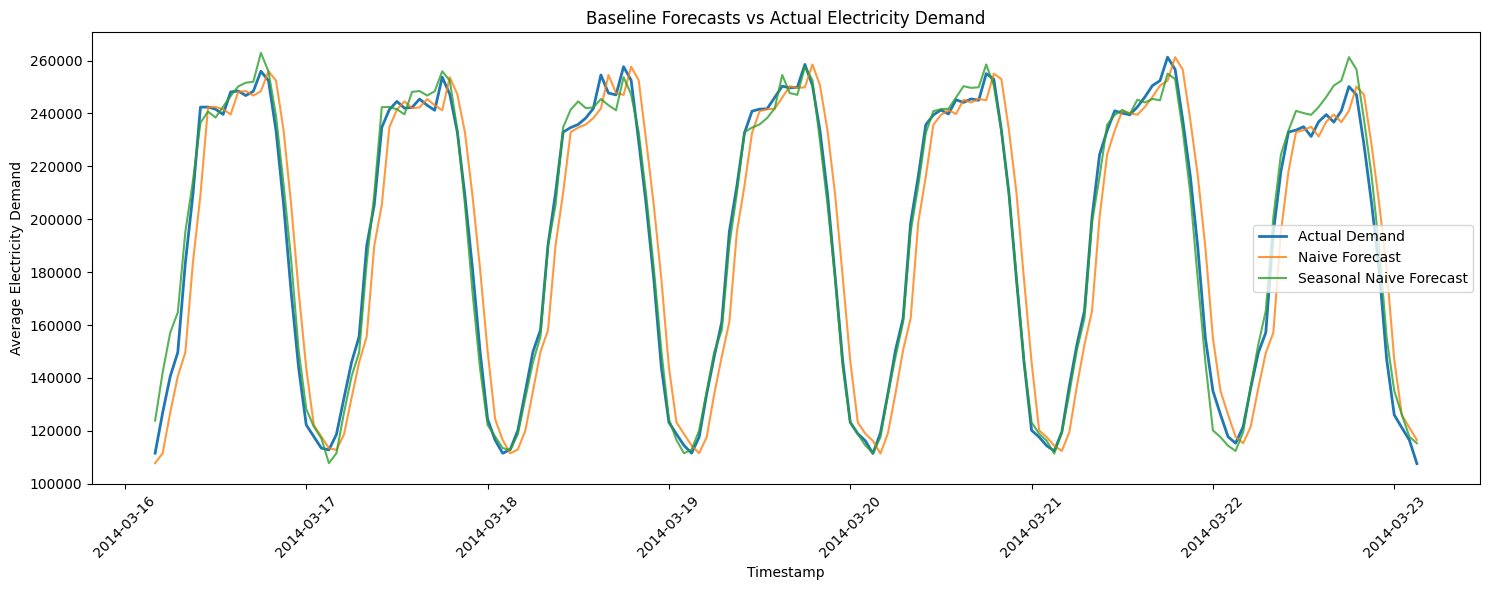

In [8]:

# Select the first 168 hours (one week) of the test period
plot_index = y_test.index[:168]

plt.figure(figsize=(15, 6))

plt.plot(
    plot_index,
    y_test.loc[plot_index],
    label="Actual Demand",
    linewidth=2
)

plt.plot(
    plot_index,
    naive_predictions.loc[plot_index],
    label="Naive Forecast",
    alpha=0.8
)

plt.plot(
    plot_index,
    seasonal_predictions.loc[plot_index],
    label="Seasonal Naive Forecast",
    alpha=0.8
)

plt.title("Baseline Forecasts vs Actual Electricity Demand")
plt.xlabel("Timestamp")
plt.ylabel("Average Electricity Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 9. Save Baseline Results

Save the evaluation metrics so that the performance of subsequent
forecasting models can be compared against these initial benchmarks.

In [9]:

from pathlib import Path

# Create the reports directory if it does not exist
reports_dir = Path("../Reports")
reports_dir.mkdir(parents=True, exist_ok=True)

# Save evaluation metrics
results_path = reports_dir / "baseline_results.csv"
baseline_results.to_csv(results_path, index=False)

print(f"Baseline results saved to: {results_path.resolve()}")

Baseline results saved to: C:\Users\Administrator\Desktop\Energy-Project\Reports\baseline_results.csv
